# Multi-Class Logistic Regression

Logistic Regression is natively binary (yes/no), but there are two standard strategies to extend it to multi-class problems:

## One-vs-All (OvA / OvR)
- Train **one classifier per class**: *"is this sample class A or not?"*
- Final prediction = class with highest probability score
- Fast: K classifiers for K classes

## One-vs-One (OvO)
- Train **one classifier per pair of classes**: *"is this A or B?"*
- Final prediction = majority vote among all classifiers
- Slower: K(K-1)/2 classifiers, but each trains on fewer samples

| Strategy | # Classifiers | Notes |
|----------|--------------|-------|
| OvA | K | Faster, standard default |
| OvO | K(K-1)/2 | Better for SVMs, comparable for LR |

**Dataset:** Obesity Risk levels — 7 classes based on eating habits, physical activity, and body metrics.

Source: https://www.kaggle.com/competitions/playground-series-s4e2

## 1. Imports

In [8]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# Add scripts directory to path so we can import pipelines.py
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'scripts'))
from pipelines import obesity_risk_pipeline

DATA_PATH = "../data/ObesityDataSet_raw_and_data_sinthetic.csv"

## 2. Data Exploration

In [9]:
data = pd.read_csv(DATA_PATH)
print(data.shape)
data.head()

(2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [10]:
data.dtypes

Gender                             object
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight     object
FAVC                               object
FCVC                              float64
NCP                               float64
CAEC                               object
SMOKE                              object
CH2O                              float64
SCC                                object
FAF                               float64
TUE                               float64
CALC                               object
MTRANS                             object
NObeyesdad                         object
dtype: object

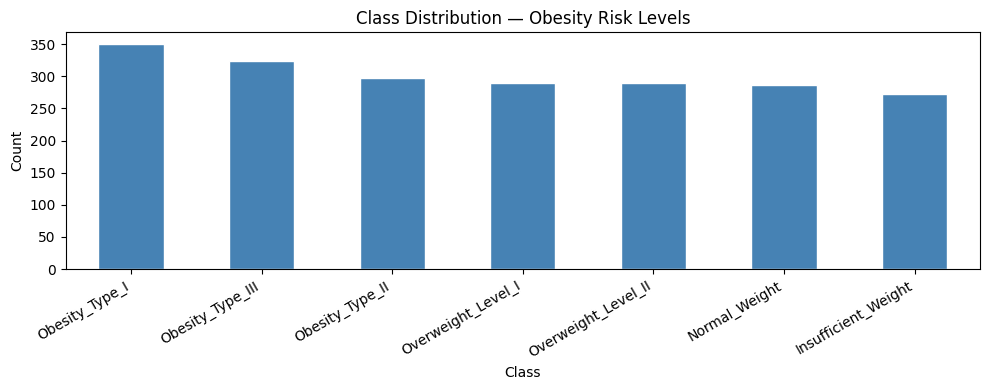

In [11]:
# Class distribution
class_counts = data["NObeyesdad"].value_counts()

plt.figure(figsize=(10, 4))
class_counts.plot(kind="bar", color="steelblue", edgecolor="white")
plt.title("Class Distribution — Obesity Risk Levels")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

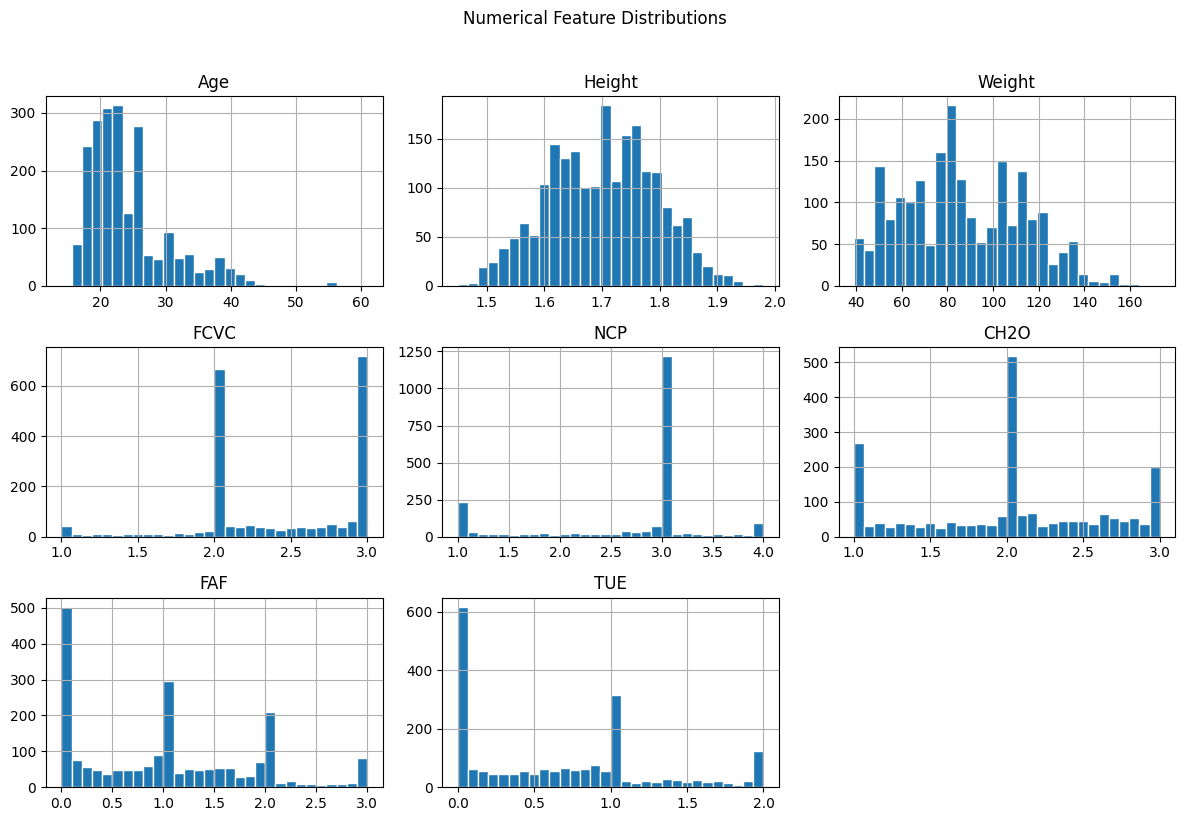

In [12]:
# Numerical feature distributions
numerical_cols = data.select_dtypes(include=["float64"]).columns

data[numerical_cols].hist(figsize=(12, 8), bins=30, edgecolor="white")
plt.suptitle("Numerical Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

## 3. Pipeline

The `obesity_risk_pipeline` function (in `scripts/pipelines.py`) handles everything in one place:

1. Loads the CSV and encodes the target with `.cat.codes`
2. Splits into train/test with stratification
3. Builds a `ColumnTransformer`: `StandardScaler` on numerical columns, `OneHotEncoder(drop='first')` on categorical ones
4. Wraps the chosen classifier in a `Pipeline` and fits it

Returning the fitted pipeline lets us call `.predict()` and `.score()` on new data without re-doing preprocessing.

## 4. Training — OvA vs OvO

In [ ]:
pipeline_ova = obesity_risk_pipeline(DATA_PATH, model_type="ova")
pipeline_ovo = obesity_risk_pipeline(DATA_PATH, model_type="ovo")

print("Pipelines trained.")
print(pipeline_ova)



c:\Users\pedro\anaconda3\envs\visao-computacional\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Pipelines trained.
Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  Index(['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE',
       'SCC', 'CALC', 'MTRANS'],
      dtype='object'))])),
                ('classifier',
                 LogisticRegression(max_iter=1000, multi_class='ovr'))])


## 5. Evaluation

The pipeline was trained inside the function, so to evaluate on the held-out test set we need to reproduce the same split. Because we used `random_state=42` and `stratify=y`, the split is deterministic.

In [14]:
# Reproduce the same split used inside the pipeline function
X = data.drop(columns="NObeyesdad")
y = data["NObeyesdad"].astype("category")
class_labels = y.cat.categories.tolist()  # original string names for plots
y_codes = y.cat.codes

_, X_test, _, y_test = train_test_split(
    X, y_codes, test_size=0.2, stratify=y_codes, random_state=42
)

y_pred_ova = pipeline_ova.predict(X_test)
y_pred_ovo = pipeline_ovo.predict(X_test)

print("=== OvA ===")
print(classification_report(y_test, y_pred_ova, target_names=class_labels))

print("\n=== OvO ===")
print(classification_report(y_test, y_pred_ovo, target_names=class_labels))

=== OvA ===
                     precision    recall  f1-score   support

Insufficient_Weight       0.90      0.96      0.93        54
      Normal_Weight       0.71      0.60      0.65        58
     Obesity_Type_I       0.63      0.74      0.68        70
    Obesity_Type_II       0.85      0.97      0.91        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.61      0.59      0.60        58
Overweight_Level_II       0.59      0.47      0.52        58

           accuracy                           0.76       423
          macro avg       0.76      0.76      0.75       423
       weighted avg       0.76      0.76      0.76       423


=== OvO ===
                     precision    recall  f1-score   support

Insufficient_Weight       0.95      1.00      0.97        54
      Normal_Weight       0.85      0.76      0.80        58
     Obesity_Type_I       0.99      0.94      0.96        70
    Obesity_Type_II       1.00      1.00      1.00      

## 6. Confusion Matrices

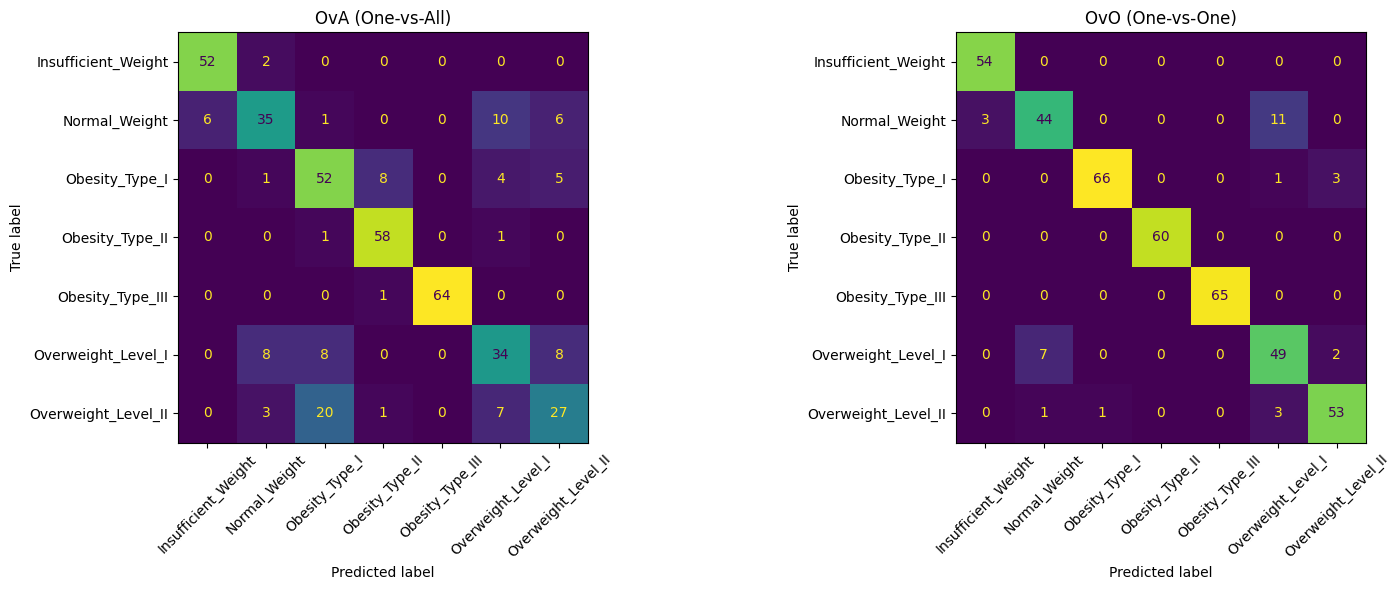

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, y_pred, title in zip(
    axes,
    [y_pred_ova, y_pred_ovo],
    ["OvA (One-vs-All)", "OvO (One-vs-One)"]
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_labels)
    disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
    ax.set_title(title)

plt.tight_layout()
plt.show()

## 7. Accuracy Comparison

OvA accuracy: 0.7612
OvO accuracy: 0.9243


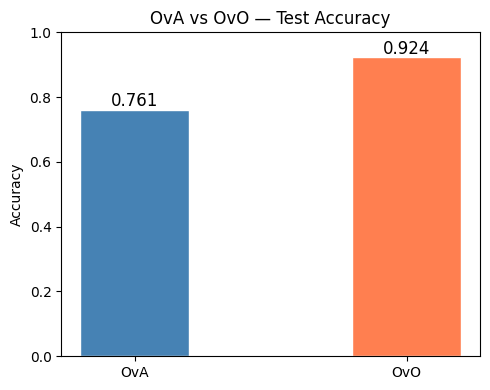

In [16]:
from sklearn.metrics import accuracy_score

acc_ova = accuracy_score(y_test, y_pred_ova)
acc_ovo = accuracy_score(y_test, y_pred_ovo)

print(f"OvA accuracy: {acc_ova:.4f}")
print(f"OvO accuracy: {acc_ovo:.4f}")

plt.figure(figsize=(5, 4))
plt.bar(["OvA", "OvO"], [acc_ova, acc_ovo], color=["steelblue", "coral"], edgecolor="white", width=0.4)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("OvA vs OvO — Test Accuracy")
for i, v in enumerate([acc_ova, acc_ovo]):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=12)
plt.tight_layout()
plt.show()

## 8. OvA Coefficient Analysis

In OvA mode, `LogisticRegression` exposes a `coef_` matrix of shape `(n_classes, n_features)`. Each row is the weight vector for one "class vs rest" binary problem — larger absolute values mean that feature matters more for that class.

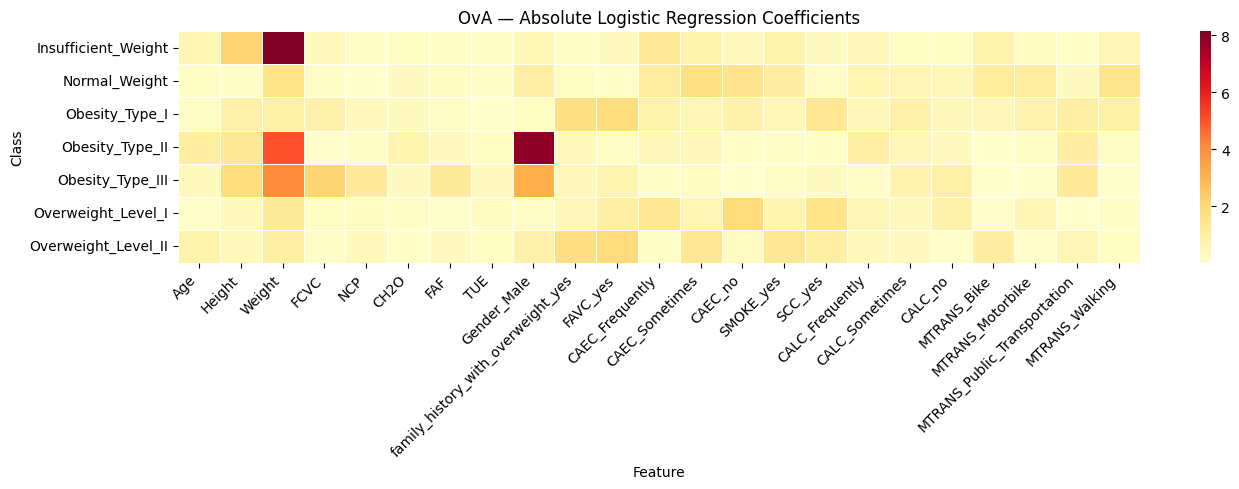

In [17]:
# Extract fitted preprocessor and classifier from OvA pipeline
preprocessor = pipeline_ova.named_steps["preprocessing"]
classifier_ova = pipeline_ova.named_steps["classifier"]

# Reconstruct feature names after ColumnTransformer
num_features = list(X.select_dtypes(include=["float64"]).columns)
cat_encoder = preprocessor.named_transformers_["cat"]
cat_features = cat_encoder.get_feature_names_out(
    X.select_dtypes(include=["object"]).columns
).tolist()
all_features = num_features + cat_features

coef_df = pd.DataFrame(
    classifier_ova.coef_,
    index=class_labels,
    columns=all_features
)

# Heatmap of absolute coefficients
plt.figure(figsize=(14, 5))
sns.heatmap(
    coef_df.abs(),
    cmap="YlOrRd",
    linewidths=0.5,
    annot=False
)
plt.title("OvA — Absolute Logistic Regression Coefficients")
plt.ylabel("Class")
plt.xlabel("Feature")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Summary

| | OvA | OvO |
|---|---|---|
| Classifiers trained | K | K(K-1)/2 |
| sklearn class | `LogisticRegression(multi_class='ovr')` | `OneVsOneClassifier(LogisticRegression())` |
| Coef access | `clf.coef_` — one row per class | not directly available |
| Typical accuracy | similar | similar |

For Logistic Regression specifically, OvA and OvO usually give nearly identical results. OvO becomes more useful for models like SVM that are inherently binary and scale poorly with large datasets.